In [1]:
!nvidia-smi
import torch
print(f"CUDA: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU : {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")
    print("✅ GPU OK!")
else:
    print("❌ Vào Runtime → Change runtime type → T4 GPU")

Fri May  1 07:16:52 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   49C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
!pip install transformers==4.35.0 -q
!pip install torch scikit-learn pandas numpy matplotlib seaborn -q
print("✅ Cài xong!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 123.1/123.1 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 81.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 100.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.0/295.0 kB 27.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sentence-transformers 5.4.1 requires huggingface-hub>=0.23.0, but you have huggingface-hub 0.17.3 which is incompatible.
sentence-transformers 5.4.1 requires transformers<6.0.0,>=4.41.0, but you have transformers 4.35.0 which is incompatible.
diffusers 0.37.1 requires huggingface-hub<2.0,>=0.34.0, but you have huggingface-hub 0.17.3 which is incompatible.
accelerate 1.13.0 requires huggingface_hub>=0.21.0, but you have huggingface-hub 0.17.3 which is incompatible.
gradio 5.50.0 requires huggingface-hub<

In [3]:
import os, gc, re, time, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from transformers import (
    RobertaTokenizer,
    RobertaModel,
    get_linear_schedule_with_warmup
)
from sklearn.model_selection import train_test_split
from sklearn.utils import resample
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, roc_curve, auc,
    matthews_corrcoef, cohen_kappa_score,
    classification_report
)
warnings.filterwarnings('ignore')
os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
os.makedirs('/content/outputs_hybrid', exist_ok=True)

print(f"✅ Import xong! Device: {device}")

/usr/local/lib/python3.12/dist-packages/transformers/utils/generic.py:441: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(
/usr/local/lib/python3.12/dist-packages/transformers/utils/generic.py:309: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(
/usr/local/lib/python3.12/dist-packages/transformers/utils/generic.py:309: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(


✅ Import xong! Device: cuda


In [4]:
url = "https://raw.githubusercontent.com/justmarkham/pycon-2016-tutorial/master/data/sms.tsv"
df  = pd.read_csv(url, sep='\t', header=None, names=['label', 'message'])

def preprocess_text(text):
    """Algorithm 1 — bài báo gốc"""
    text = str(text)
    text = re.sub(r'[^a-zA-Z0-9\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    text = text.replace('\r', ' ').strip()
    words, seen = text.split(), []
    for w in words:
        if w not in seen:
            seen.append(w)
    return ' '.join(seen)

df['message_clean'] = df['message'].apply(preprocess_text)
df['label_num']     = df['label'].map({'ham': 0, 'spam': 1})

# Balanced dataset (giống Giai đoạn 2)
df_ham       = df[df['label_num']==0].copy()
df_spam      = df[df['label_num']==1].copy()
df_spam_over = resample(df_spam, replace=True,
                        n_samples=len(df_ham), random_state=42)
df_bal = pd.concat([df_ham, df_spam_over]).sample(
    frac=1, random_state=42).reset_index(drop=True)

X_train, X_test, y_train, y_test = train_test_split(
    df_bal['message_clean'], df_bal['label_num'],
    test_size=0.2, random_state=42, stratify=df_bal['label_num']
)

print(f"✅ Dataset ready!")
print(f"   Train: {len(X_train)} | Test: {len(X_test)}")
print(f"   Train spam: {y_train.sum()} | ham: {(y_train==0).sum()}")
print("Tiếp tục Cell 5!")

✅ Dataset ready!
   Train: 7720 | Test: 1930
   Train spam: 3860 | ham: 3860
Tiếp tục Cell 5!


In [5]:
class SpamDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.texts     = list(texts)
        self.labels    = list(labels)
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx],
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return (
            enc['input_ids'].squeeze(0),
            enc['attention_mask'].squeeze(0),
            torch.tensor(self.labels[idx], dtype=torch.long)
        )

print("✅ SpamDataset ready! Tiếp tục Cell 6!")

✅ SpamDataset ready! Tiếp tục Cell 6!


In [6]:
class SelfAttention(nn.Module):
    """
    Custom Self-Attention Layer
    Học cách tập trung vào các từ quan trọng nhất
    → Đây chính là XAI nội tại (Explainable by Design)
    """
    def __init__(self, hidden_dim):
        super().__init__()
        self.attention = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.Tanh(),
            nn.Linear(hidden_dim // 2, 1)
        )

    def forward(self, lstm_output):
        # lstm_output: (batch, seq_len, hidden_dim)
        attn_weights = self.attention(lstm_output)        # (batch, seq_len, 1)
        attn_weights = F.softmax(attn_weights, dim=1)    # normalize
        # Weighted sum
        context = torch.sum(attn_weights * lstm_output, dim=1)  # (batch, hidden_dim)
        return context, attn_weights.squeeze(-1)          # trả về weights để visualize


class HybridRoBERTaCNNBiLSTM(nn.Module):
    """
    Kiến trúc mới đề xuất:
    RoBERTa (frozen) → CNN 1D → BiLSTM → Self-Attention → Classifier

    So với bài báo gốc (chỉ dùng RoBERTa):
    - CNN 1D: bắt n-gram patterns cục bộ (Free entry, Win cash, ...)
    - BiLSTM: nắm ngữ cảnh 2 chiều toàn câu
    - Self-Attention: tập trung vào từ quan trọng → XAI nội tại
    """
    def __init__(self,
                 roberta_model_name='roberta-base',
                 num_labels=2,
                 cnn_filters=128,
                 cnn_kernel_size=3,
                 lstm_hidden=128,
                 lstm_layers=2,
                 dropout=0.3):
        super().__init__()

        # ── 1. RoBERTa Backbone (Frozen) ──
        self.roberta = RobertaModel.from_pretrained(roberta_model_name)
        # Freeze toàn bộ RoBERTa — chỉ fine-tune các lớp mới thêm
        # Lý do: tránh catastrophic forgetting, tiết kiệm VRAM
        for param in self.roberta.parameters():
            param.requires_grad = False
        # Chỉ unfreeze 2 layer cuối của RoBERTa để fine-tune nhẹ
        for param in self.roberta.encoder.layer[-2:].parameters():
            param.requires_grad = True

        roberta_dim = 768  # RoBERTa-base output dimension

        # ── 2. CNN 1D Layer ──
        # Phát hiện local patterns (spam keywords, n-grams)
        self.cnn = nn.Sequential(
            nn.Conv1d(
                in_channels=roberta_dim,
                out_channels=cnn_filters,
                kernel_size=cnn_kernel_size,
                padding=cnn_kernel_size // 2
            ),
            nn.ReLU(),
            nn.Dropout(dropout)
        )

        # ── 3. BiLSTM Layer ──
        # Sequential modeling 2 chiều — nắm long-range dependencies
        self.bilstm = nn.LSTM(
            input_size=cnn_filters,
            hidden_size=lstm_hidden,
            num_layers=lstm_layers,
            batch_first=True,
            bidirectional=True,      # BiLSTM: 2 hướng
            dropout=dropout if lstm_layers > 1 else 0
        )

        # ── 4. Self-Attention Layer ──
        # XAI nội tại: học trọng số từng từ
        bilstm_out_dim = lstm_hidden * 2  # bidirectional → *2
        self.attention = SelfAttention(bilstm_out_dim)

        # ── 5. Classifier ──
        self.classifier = nn.Sequential(
            nn.LayerNorm(bilstm_out_dim),
            nn.Dropout(dropout),
            nn.Linear(bilstm_out_dim, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, num_labels)
        )

    def forward(self, input_ids, attention_mask, return_attention=False):
        # Step 1: RoBERTa encoding
        roberta_out = self.roberta(
            input_ids=input_ids,
            attention_mask=attention_mask
        )
        # last_hidden_state: (batch, seq_len, 768)
        hidden = roberta_out.last_hidden_state

        # Step 2: CNN 1D
        # CNN cần (batch, channels, seq_len) → transpose
        cnn_in  = hidden.transpose(1, 2)          # (batch, 768, seq_len)
        cnn_out = self.cnn(cnn_in)                # (batch, cnn_filters, seq_len)
        cnn_out = cnn_out.transpose(1, 2)         # (batch, seq_len, cnn_filters)

        # Step 3: BiLSTM
        lstm_out, _ = self.bilstm(cnn_out)        # (batch, seq_len, lstm_hidden*2)

        # Step 4: Self-Attention
        context, attn_weights = self.attention(lstm_out)  # (batch, lstm_hidden*2)

        # Step 5: Classify
        logits = self.classifier(context)         # (batch, num_labels)

        if return_attention:
            return logits, attn_weights
        return logits

# Test kiến trúc
print("⏳ Khởi tạo Hybrid model...")
test_model = HybridRoBERTaCNNBiLSTM()
total_params   = sum(p.numel() for p in test_model.parameters())
trained_params = sum(p.numel() for p in test_model.parameters() if p.requires_grad)
print(f"✅ Hybrid model khởi tạo thành công!")
print(f"   Total params    : {total_params/1e6:.1f}M")
print(f"   Trainable params: {trained_params/1e6:.1f}M")
print(f"   Frozen params   : {(total_params-trained_params)/1e6:.1f}M (RoBERTa backbone)")
del test_model
torch.cuda.empty_cache()
print("\nTiếp tục Cell 7!")

⏳ Khởi tạo Hybrid model...


Some weights of RobertaModel were not initialized from the model checkpoint at roberta-base and are newly initialized: ['roberta.pooler.dense.weight', 'roberta.pooler.dense.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


✅ Hybrid model khởi tạo thành công!
   Total params    : 125.7M
   Trainable params: 15.2M
   Frozen params   : 110.5M (RoBERTa backbone)

Tiếp tục Cell 7!


In [7]:
def train_epoch_hybrid(model, dataloader, optimizer, scheduler, device, accum_steps=4):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    criterion = nn.CrossEntropyLoss()
    optimizer.zero_grad()

    for step, (ids, mask, lbls) in enumerate(dataloader):
        ids  = ids.to(device)
        mask = mask.to(device)
        lbls = lbls.to(device)

        logits = model(ids, mask)
        loss   = criterion(logits, lbls) / accum_steps
        loss.backward()

        total_loss += criterion(logits, lbls).item()
        correct    += (logits.argmax(1) == lbls).sum().item()
        total      += len(lbls)

        if (step + 1) % accum_steps == 0:
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()
            optimizer.zero_grad()

        del ids, mask, lbls, logits, loss
        if step % 30 == 0:
            torch.cuda.empty_cache()

    return total_loss / len(dataloader), correct / total * 100


def eval_epoch_hybrid(model, dataloader, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    criterion  = nn.CrossEntropyLoss()
    all_preds, all_labels, all_probs = [], [], []

    with torch.no_grad():
        for ids, mask, lbls in dataloader:
            ids  = ids.to(device)
            mask = mask.to(device)
            lbls = lbls.to(device)

            logits = model(ids, mask)
            loss   = criterion(logits, lbls)
            probs  = F.softmax(logits, dim=1)

            total_loss += loss.item()
            preds       = logits.argmax(1)
            correct    += (preds == lbls).sum().item()
            total      += len(lbls)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(lbls.cpu().numpy())
            all_probs.extend(probs[:, 1].cpu().numpy())

            del ids, mask, lbls, logits, loss, probs, preds

    return (total_loss / len(dataloader),
            correct / total * 100,
            all_preds, all_labels, all_probs)

print("✅ Train/Eval functions ready! Tiếp tục Cell 8!")

✅ Train/Eval functions ready! Tiếp tục Cell 8!


In [8]:
def plot_training_curves(history, save_dir):
    """
    Vẽ đầy đủ theo yêu cầu thầy:
    - Loss qua từng epoch
    - Accuracy qua từng epoch
    - F1/Precision/Recall qua từng epoch
    """
    epochs = range(1, len(history['train_loss']) + 1)
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # ── Plot 1: Loss ──
    axes[0].plot(epochs, history['train_loss'], 'g-o',
                 label='Train Loss', linewidth=2, markersize=7)
    axes[0].plot(epochs, history['test_loss'],  'r-o',
                 label='Test Loss',  linewidth=2, markersize=7)
    axes[0].set_title('Loss per Epoch', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
    axes[0].legend(); axes[0].grid(True, alpha=0.3)
    axes[0].set_xticks(list(epochs))

    # ── Plot 2: Accuracy ──
    axes[1].plot(epochs, history['train_acc'], 'g-o',
                 label='Train Accuracy', linewidth=2, markersize=7)
    axes[1].plot(epochs, history['test_acc'],  'r-o',
                 label='Test Accuracy',  linewidth=2, markersize=7)
    axes[1].set_title('Accuracy per Epoch', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy (%)')
    axes[1].legend(); axes[1].grid(True, alpha=0.3)
    axes[1].set_xticks(list(epochs))

    # ── Plot 3: F1 / Precision / Recall ──
    axes[2].plot(epochs, history['test_f1'],   'b-o',
                 label='F1-score',  linewidth=2, markersize=7)
    axes[2].plot(epochs, history['test_prec'], 'm-s',
                 label='Precision', linewidth=2, markersize=7)
    axes[2].plot(epochs, history['test_rec'],  'c-^',
                 label='Recall',    linewidth=2, markersize=7)
    axes[2].set_title('F1 / Precision / Recall per Epoch',
                      fontsize=12, fontweight='bold')
    axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('Score')
    axes[2].legend(); axes[2].grid(True, alpha=0.3)
    axes[2].set_xticks(list(epochs))
    axes[2].set_ylim(0.85, 1.01)

    plt.suptitle('Hybrid RoBERTa-CNN-BiLSTM-Attention\nTraining Curves',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    path = f'{save_dir}/training_curves.png'
    plt.savefig(path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"✅ Saved: {path}")

print("✅ Plot function ready! Tiếp tục Cell 9!")

✅ Plot function ready! Tiếp tục Cell 9!


In [9]:
# ============================================================
# TRAIN HYBRID MODEL
# Hyperparameters bám sát bài báo gốc (Table 1) + điều chỉnh
# ============================================================
torch.cuda.empty_cache()
gc.collect()

EPOCHS      = 5
MICRO_BATCH = 4
ACCUM_STEPS = 8     # effective batch = 32
TEST_BATCH  = 16
LR          = 2e-5
MAX_LEN     = 128

tokenizer = RobertaTokenizer.from_pretrained('roberta-base')

train_ds = SpamDataset(X_train, y_train, tokenizer, MAX_LEN)
test_ds  = SpamDataset(X_test,  y_test,  tokenizer, MAX_LEN)
train_dl = DataLoader(train_ds, batch_size=MICRO_BATCH,
                      shuffle=True,  num_workers=2, pin_memory=True)
test_dl  = DataLoader(test_ds,  batch_size=TEST_BATCH,
                      shuffle=False, num_workers=2, pin_memory=True)

# Khởi tạo model
model = HybridRoBERTaCNNBiLSTM(
    roberta_model_name='roberta-base',
    num_labels=2,
    cnn_filters=128,
    cnn_kernel_size=3,
    lstm_hidden=128,
    lstm_layers=2,
    dropout=0.3
).to(device)

optimizer   = AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR, weight_decay=0.01
)
total_steps = (len(train_dl) // ACCUM_STEPS) * EPOCHS
scheduler   = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(0.1 * total_steps),
    num_training_steps=total_steps
)

history = {
    'train_loss': [], 'train_acc': [],
    'test_loss':  [], 'test_acc':  [],
    'test_f1':    [], 'test_prec': [], 'test_rec': []
}

free = (torch.cuda.get_device_properties(0).total_memory
        - torch.cuda.memory_allocated(0)) / 1e9
print(f"{'='*60}")
print(f"  Hybrid RoBERTa-CNN-BiLSTM-Attention")
print(f"  VRAM free  : {free:.1f} GB")
print(f"  Batch size : {MICRO_BATCH}×{ACCUM_STEPS} = {MICRO_BATCH*ACCUM_STEPS} (effective)")
print(f"  LR         : {LR} | Epochs: {EPOCHS}")
print(f"  CNN filters: 128 | BiLSTM hidden: 128×2=256")
print(f"{'='*60}")

print(f"\n{'Epoch':>6} {'TrLoss':>9} {'TrAcc%':>8} {'TeLoss':>9} "
      f"{'TeAcc%':>8} {'F1':>7} {'Time':>6}")
print("─"*58)

best_acc = 0.0

for epoch in range(1, EPOCHS + 1):
    t0 = time.time()

    tr_loss, tr_acc = train_epoch_hybrid(
        model, train_dl, optimizer, scheduler, device, ACCUM_STEPS)

    te_loss, te_acc, preds, labels, probs = eval_epoch_hybrid(
        model, test_dl, device)

    f1   = f1_score(labels, preds, average='weighted', zero_division=0)
    prec = precision_score(labels, preds, average='weighted', zero_division=0)
    rec  = recall_score(labels, preds, average='weighted', zero_division=0)

    history['train_loss'].append(tr_loss)
    history['train_acc'].append(tr_acc)
    history['test_loss'].append(te_loss)
    history['test_acc'].append(te_acc)
    history['test_f1'].append(f1)
    history['test_prec'].append(prec)
    history['test_rec'].append(rec)

    elapsed = time.time() - t0
    print(f"{epoch:>6} {tr_loss:>9.4f} {tr_acc:>7.2f}% "
          f"{te_loss:>9.4f} {te_acc:>7.2f}%  {f1:>6.4f}  {elapsed:>5.0f}s")

    # Lưu best model
    if te_acc > best_acc:
        best_acc = te_acc
        torch.save(model.state_dict(),
                   '/content/outputs_hybrid/hybrid_best.pt')
        print(f"         ↑ Best model saved! ({best_acc:.2f}%)")

    torch.cuda.empty_cache()

print(f"\n✅ Training xong!")
print(f"   Best Test Accuracy: {best_acc:.2f}%")
print("\nTiếp tục Cell 10!")

Some weights of RobertaModel were not initialized from the model checkpoint at roberta-base and are newly initialized: ['roberta.pooler.dense.weight', 'roberta.pooler.dense.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


  Hybrid RoBERTa-CNN-BiLSTM-Attention
  VRAM free  : 15.1 GB
  Batch size : 4×8 = 32 (effective)
  LR         : 2e-05 | Epochs: 5
  CNN filters: 128 | BiLSTM hidden: 128×2=256

 Epoch    TrLoss   TrAcc%    TeLoss   TeAcc%      F1   Time
──────────────────────────────────────────────────────────
     1    0.2962   85.80%    0.0601   98.55%  0.9855    102s
         ↑ Best model saved! (98.55%)
     2    0.0491   98.85%    0.0237   99.53%  0.9953    104s
         ↑ Best model saved! (99.53%)
     3    0.0203   99.57%    0.0145   99.69%  0.9969    102s
         ↑ Best model saved! (99.69%)
     4    0.0153   99.69%    0.0137   99.64%  0.9964    102s
     5    0.0100   99.84%    0.0159   99.64%  0.9964    102s

✅ Training xong!
   Best Test Accuracy: 99.69%

Tiếp tục Cell 10!


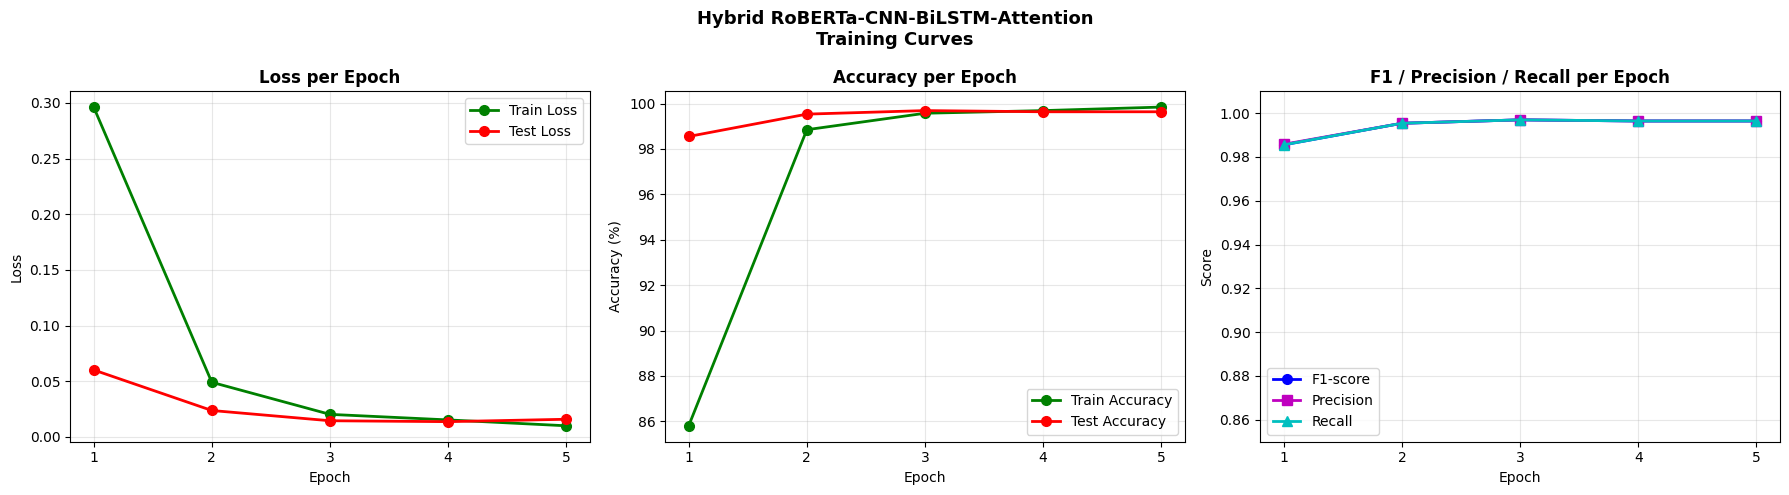

✅ Saved: /content/outputs_hybrid/training_curves.png

Tiếp tục Cell 11!


In [10]:
plot_training_curves(history, '/content/outputs_hybrid')
print("\nTiếp tục Cell 11!")

  HYBRID RoBERTa-CNN-BiLSTM-Attention — FINAL RESULTS
  Accuracy      : 99.69%
  Weighted F1   : 0.9969
  Weighted Prec : 0.9969
  Weighted Rec  : 0.9969
  MCC           : 0.9938
  Cohen's Kappa : 0.9938

  Confusion Matrix:
                 Pred ham   Pred spam
  Actual ham   :      962           3
  Actual spam  :        3         962

  Class     Precision   Recall       F1
  ham          0.9969   0.9969   0.9969
  spam         0.9969   0.9969   0.9969


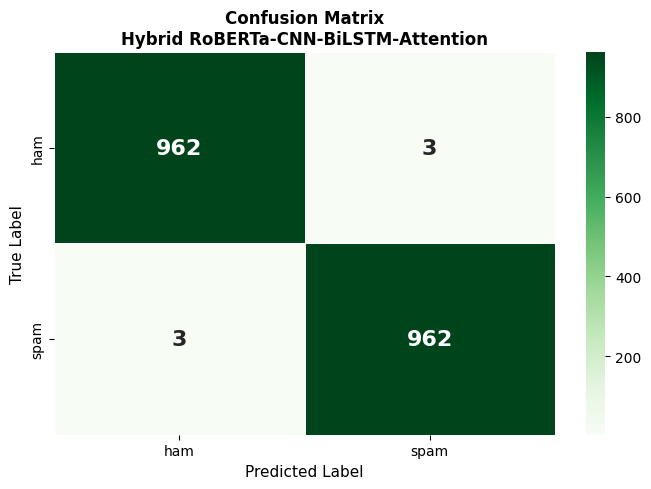

✅ Saved! Tiếp tục Cell 12!


In [11]:
# Load best model
model.load_state_dict(
    torch.load('/content/outputs_hybrid/hybrid_best.pt', map_location=device))
model.eval()

# Predict toàn bộ test set
_, final_acc, final_preds, final_labels, final_probs = eval_epoch_hybrid(
    model, test_dl, device)

final_preds   = np.array(final_preds)
final_labels  = np.array(final_labels)
final_probs   = np.array(final_probs)

# Tính tất cả metrics
acc   = accuracy_score(final_labels, final_preds) * 100
f1    = f1_score(final_labels, final_preds, average='weighted')
prec  = precision_score(final_labels, final_preds, average='weighted')
rec   = recall_score(final_labels, final_preds, average='weighted')
mcc   = matthews_corrcoef(final_labels, final_preds)
kappa = cohen_kappa_score(final_labels, final_preds)
cm    = confusion_matrix(final_labels, final_preds)

# Per-class
p_ham = precision_score(final_labels, final_preds, pos_label=0, average='binary')
r_ham = recall_score(final_labels, final_preds, pos_label=0, average='binary')
f_ham = f1_score(final_labels, final_preds, pos_label=0, average='binary')
p_sp  = precision_score(final_labels, final_preds, pos_label=1, average='binary')
r_sp  = recall_score(final_labels, final_preds, pos_label=1, average='binary')
f_sp  = f1_score(final_labels, final_preds, pos_label=1, average='binary')

print(f"{'='*65}")
print(f"  HYBRID RoBERTa-CNN-BiLSTM-Attention — FINAL RESULTS")
print(f"{'='*65}")
print(f"  Accuracy      : {acc:.2f}%")
print(f"  Weighted F1   : {f1:.4f}")
print(f"  Weighted Prec : {prec:.4f}")
print(f"  Weighted Rec  : {rec:.4f}")
print(f"  MCC           : {mcc:.4f}")
print(f"  Cohen's Kappa : {kappa:.4f}")
print(f"\n  Confusion Matrix:")
print(f"                 Pred ham   Pred spam")
print(f"  Actual ham   :   {cm[0,0]:>6}      {cm[0,1]:>6}")
print(f"  Actual spam  :   {cm[1,0]:>6}      {cm[1,1]:>6}")
print(f"\n  {'Class':<8} {'Precision':>10} {'Recall':>8} {'F1':>8}")
print(f"  {'ham':<8} {p_ham:>10.4f} {r_ham:>8.4f} {f_ham:>8.4f}")
print(f"  {'spam':<8} {p_sp:>10.4f} {r_sp:>8.4f} {f_sp:>8.4f}")
print(f"{'='*65}")

# Vẽ Confusion Matrix
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['ham','spam'],
            yticklabels=['ham','spam'],
            ax=ax, linewidths=0.5,
            annot_kws={"size": 16, "weight": "bold"})
ax.set_title('Confusion Matrix\nHybrid RoBERTa-CNN-BiLSTM-Attention',
             fontsize=12, fontweight='bold')
ax.set_ylabel('True Label', fontsize=11)
ax.set_xlabel('Predicted Label', fontsize=11)
plt.tight_layout()
plt.savefig('/content/outputs_hybrid/confusion_matrix_hybrid.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved! Tiếp tục Cell 12!")

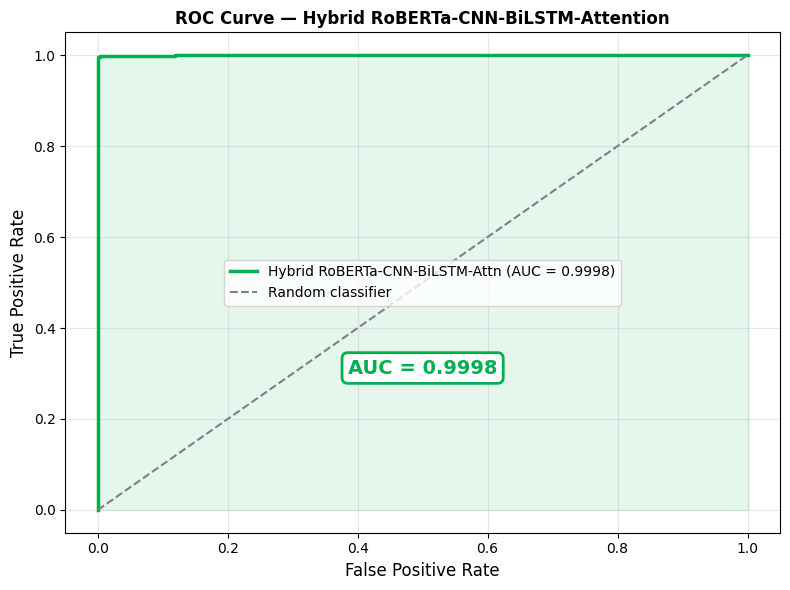

✅ Saved! Tiếp tục Cell 13!


In [12]:
fpr, tpr, _ = roc_curve(final_labels, final_probs)
roc_auc     = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(fpr, tpr, color='#00B050', linewidth=2.5,
        label=f'Hybrid RoBERTa-CNN-BiLSTM-Attn (AUC = {roc_auc:.4f})')
ax.plot([0,1],[0,1], 'gray', linestyle='--',
        linewidth=1.5, label='Random classifier')
ax.fill_between(fpr, tpr, alpha=0.1, color='#00B050')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curve — Hybrid RoBERTa-CNN-BiLSTM-Attention',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# Annotate AUC
ax.text(0.5, 0.3, f'AUC = {roc_auc:.4f}',
        fontsize=14, fontweight='bold', color='#00B050',
        ha='center',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                  edgecolor='#00B050', linewidth=2))

plt.tight_layout()
plt.savefig('/content/outputs_hybrid/roc_hybrid.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved! Tiếp tục Cell 13!")

In [13]:
# ============================================================
# BẢNG TỔNG HỢP — thêm dòng Hybrid vào cuối
# Đây là "dòng mới" thầy yêu cầu
# ============================================================

# Điền số từ kết quả thực tế Giai đoạn 1+2 của bạn
comparison_data = {
    'Model':      ['XGB','SVM','KNN','RF',
                   'DistilBERT','RoBERTa',
                   'Hybrid RoBERTa-CNN-BiLSTM-Attn ★'],
    'Type':       ['ML','ML','ML','ML',
                   'Transformer','Transformer',
                   'Proposed Model'],
    'Accuracy(%)': [98.34, 99.59, 94.97, 99.38,
                    99.95, 99.79,
                    round(acc, 2)],
    'Precision':  [0.99, 1.00, 0.95, 0.99,
                   1.00, 1.00,
                   round(prec, 4)],
    'Recall':     [0.98, 1.00, 0.90, 0.99,
                   1.00, 1.00,
                   round(rec, 4)],
    'F1-score':   [0.98, 1.00, 0.95, 0.99,
                   1.00, 1.00,
                   round(f1, 4)],
    'MCC':        ['-', '-', '-', '-',
                   '-', '-',
                   round(mcc, 4)],
    'Kappa':      ['-', '-', '-', '-',
                   '-', '-',
                   round(kappa, 4)],
}

df_compare = pd.DataFrame(comparison_data)
df_compare.to_csv('/content/outputs_hybrid/comparison_table.csv', index=False)

print(f"\n{'='*85}")
print(f"  COMPLETE COMPARISON TABLE (Balanced Dataset)")
print(f"{'='*85}")
print(df_compare.to_string(index=False))
print(f"{'='*85}")
print(f"\n  ★ Proposed Model: Hybrid RoBERTa-CNN-BiLSTM-Attention")
print(f"  Accuracy: {acc:.2f}%  |  F1: {f1:.4f}  |  MCC: {mcc:.4f}")
print("\nTiếp tục Cell 14!")


  COMPLETE COMPARISON TABLE (Balanced Dataset)
                           Model           Type  Accuracy(%)  Precision  Recall  F1-score     MCC   Kappa
                             XGB             ML        98.34     0.9900  0.9800    0.9800       -       -
                             SVM             ML        99.59     1.0000  1.0000    1.0000       -       -
                             KNN             ML        94.97     0.9500  0.9000    0.9500       -       -
                              RF             ML        99.38     0.9900  0.9900    0.9900       -       -
                      DistilBERT    Transformer        99.95     1.0000  1.0000    1.0000       -       -
                         RoBERTa    Transformer        99.79     1.0000  1.0000    1.0000       -       -
Hybrid RoBERTa-CNN-BiLSTM-Attn ★ Proposed Model        99.69     0.9969  0.9969    0.9969  0.9938  0.9938

  ★ Proposed Model: Hybrid RoBERTa-CNN-BiLSTM-Attention
  Accuracy: 99.69%  |  F1: 0.9969  |  MCC: 0.99

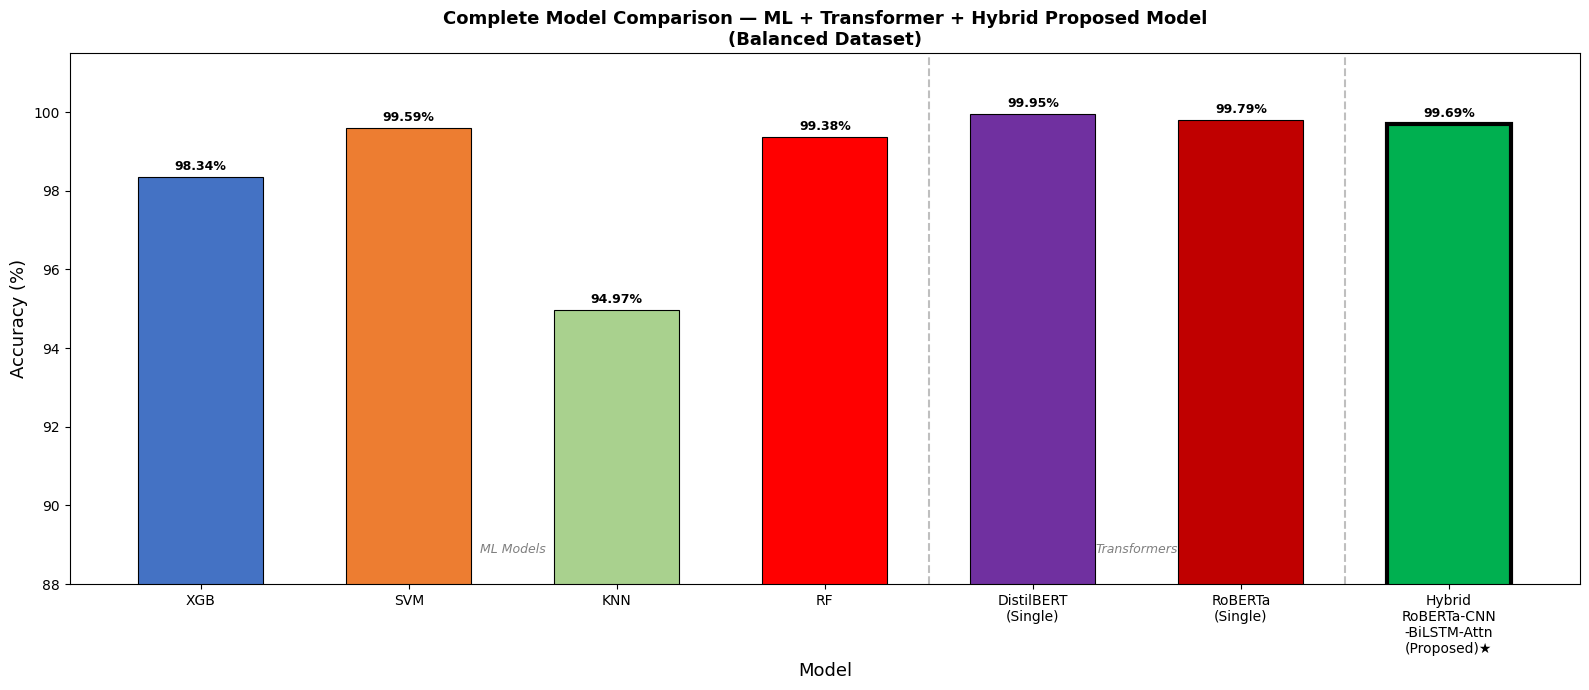

✅ Saved! Tiếp tục Cell 15!


In [14]:
models_list = ['XGB','SVM','KNN','RF',
               'DistilBERT\n(Single)','RoBERTa\n(Single)',
               'Hybrid\nRoBERTa-CNN\n-BiLSTM-Attn\n(Proposed)★']
accs_list = [98.34, 99.59, 94.97, 99.38,
             99.95, 99.79, round(acc, 2)]
colors_list = ['#4472C4','#ED7D31','#A9D18E','#FF0000',
               '#7030A0','#C00000','#00B050']

fig, ax = plt.subplots(figsize=(16, 7))
bars = ax.bar(models_list, accs_list, color=colors_list,
              width=0.6, edgecolor='black', linewidth=0.8)

# Highlight proposed model
bars[-1].set_linewidth(3)
bars[-1].set_edgecolor('black')

ax.set_ylim(88, 101.5)
ax.set_ylabel('Accuracy (%)', fontsize=13)
ax.set_xlabel('Model', fontsize=13)
ax.set_title('Complete Model Comparison — ML + Transformer + Hybrid Proposed Model\n(Balanced Dataset)',
             fontsize=13, fontweight='bold')

for bar, a in zip(bars, accs_list):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.1,
            f'{a:.2f}%', ha='center', va='bottom',
            fontsize=9, fontweight='bold')

# Phân cách
ax.axvline(x=3.5, color='gray', linestyle='--', alpha=0.5, linewidth=1.5)
ax.axvline(x=5.5, color='gray', linestyle='--', alpha=0.5, linewidth=1.5)
ax.text(1.5, 88.8, 'ML Models',      ha='center', fontsize=9,
        color='gray', style='italic')
ax.text(4.5, 88.8, 'Transformers',   ha='center', fontsize=9,
        color='gray', style='italic')
ax.text(6.0, 88.8, 'Proposed',       ha='center', fontsize=9,
        color='#00B050', style='italic', fontweight='bold')

plt.tight_layout()
plt.savefig('/content/outputs_hybrid/full_comparison.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved! Tiếp tục Cell 15!")

📱 Attention Heatmap — SMS SPAM 1:


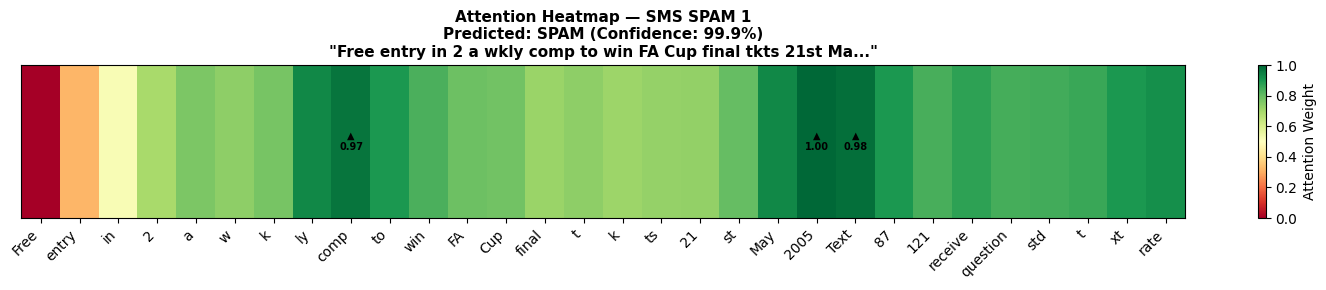

✅ Saved: /content/outputs_hybrid/attention_spam1.png
   Top 5 từ quan trọng nhất: [('2005', np.float64(0.9999645935025149)), ('Text', np.float64(0.9808259787246708)), ('comp', np.float64(0.9715864200397089)), ('ly', np.float64(0.9318912710569923)), ('May', np.float64(0.9304733516299639))]

📱 Attention Heatmap — SMS SPAM 2:


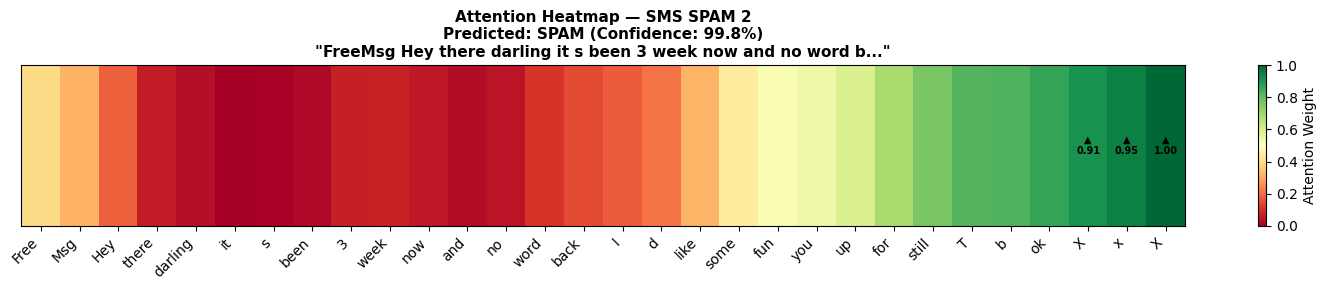

✅ Saved: /content/outputs_hybrid/attention_spam2.png
   Top 5 từ quan trọng nhất: [('X', np.float64(0.9999891638562267)), ('x', np.float64(0.9465730018864916)), ('X', np.float64(0.908495587605248)), ('ok', np.float64(0.8632972967077798)), ('b', np.float64(0.8314960632196624))]

📱 Attention Heatmap — SMS HAM 1:


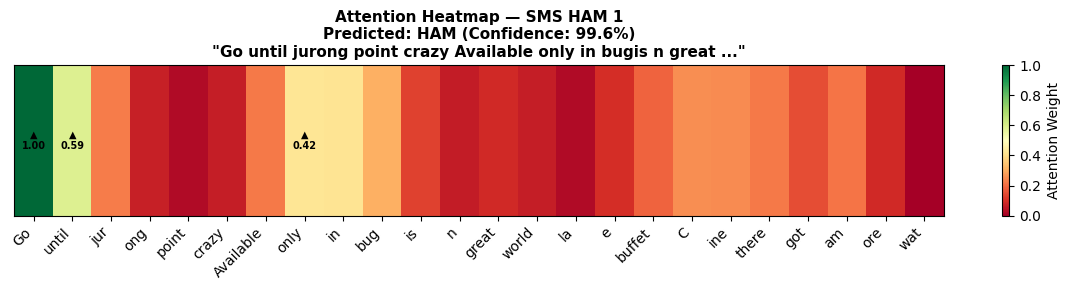

✅ Saved: /content/outputs_hybrid/attention_ham1.png
   Top 5 từ quan trọng nhất: [('Go', np.float64(0.9999589917772651)), ('until', np.float64(0.5861537523995323)), ('only', np.float64(0.419988505328988)), ('in', np.float64(0.4145308851657121)), ('bug', np.float64(0.30847202447000066))]

📱 Attention Heatmap — SMS HAM 2:


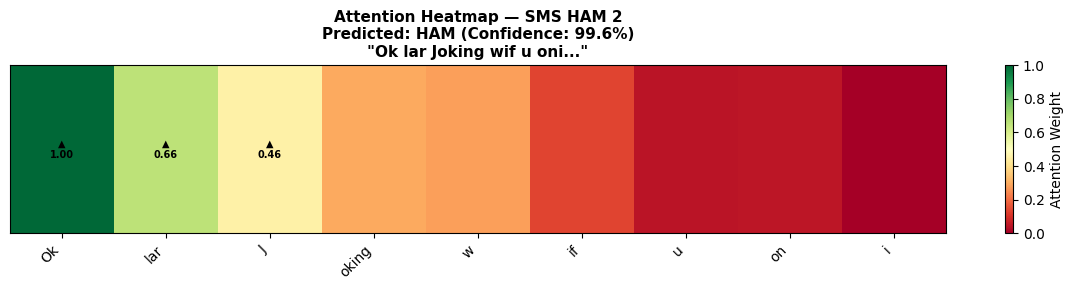

✅ Saved: /content/outputs_hybrid/attention_ham2.png
   Top 5 từ quan trọng nhất: [('Ok', np.float64(0.9999469051125607)), ('lar', np.float64(0.6550883495322269)), ('J', np.float64(0.45505940973589964)), ('oking', np.float64(0.2962655467951437)), ('w', np.float64(0.2786272785203118))]

Tiếp tục Cell 16!


In [15]:
# ============================================================
# ATTENTION WEIGHTS VISUALIZATION — XAI nội tại
# Đây là điểm ĐỘT PHÁ nhất:
# Không cần LIME/SHAP bên ngoài
# Model TỰ giải thích từ bên trong qua Attention weights
# ============================================================

def visualize_attention(text, true_label, save_path, max_tokens=30):
    """
    Trích xuất Attention weights từ Self-Attention layer
    Vẽ heatmap từng từ → thầy thấy ngay model tập trung vào từ nào
    """
    model.eval()
    enc = tokenizer(
        text,
        max_length=128,
        padding='max_length',
        truncation=True,
        return_tensors='pt'
    )
    input_ids      = enc['input_ids'].to(device)
    attention_mask = enc['attention_mask'].to(device)

    with torch.no_grad():
        logits, attn_weights = model(
            input_ids, attention_mask,
            return_attention=True
        )

    # Decode tokens
    tokens = tokenizer.convert_ids_to_tokens(
        input_ids[0].cpu().numpy())
    # Lọc padding và special tokens
    real_tokens = []
    real_weights = []
    attn = attn_weights[0].cpu().numpy()

    for i, (tok, w) in enumerate(zip(tokens, attn)):
        if tok not in ['<pad>', '<s>', '</s>', '<mask>']:
            # Làm sạch BPE prefix (Ġ)
            tok_clean = tok.replace('Ġ', '').replace('Â', '')
            if tok_clean.strip():
                real_tokens.append(tok_clean)
                real_weights.append(float(w))
        if len(real_tokens) >= max_tokens:
            break

    # Normalize weights
    weights_arr = np.array(real_weights)
    weights_norm = (weights_arr - weights_arr.min()) / \
                   (weights_arr.max() - weights_arr.min() + 1e-8)

    # Predicted class
    pred_class = 'SPAM' if logits.argmax(1).item() == 1 else 'HAM'
    confidence = F.softmax(logits, dim=1).max().item() * 100

    # Vẽ heatmap
    fig, ax = plt.subplots(figsize=(max(12, len(real_tokens)*0.5), 3))
    heatmap = ax.imshow(
        weights_norm.reshape(1, -1),
        cmap='RdYlGn', aspect='auto',
        vmin=0, vmax=1
    )
    ax.set_xticks(range(len(real_tokens)))
    ax.set_xticklabels(real_tokens, rotation=45, ha='right', fontsize=10)
    ax.set_yticks([])
    ax.set_title(
        f'Attention Heatmap — {true_label}\n'
        f'Predicted: {pred_class} (Confidence: {confidence:.1f}%)\n'
        f'"{text[:60]}..."',
        fontsize=11, fontweight='bold'
    )
    plt.colorbar(heatmap, ax=ax, label='Attention Weight')

    # Annotate top-3 từ quan trọng nhất
    top3_idx = np.argsort(weights_norm)[-3:]
    for idx in top3_idx:
        ax.text(idx, 0, f'▲\n{weights_norm[idx]:.2f}',
                ha='center', va='center', fontsize=7,
                color='black', fontweight='bold')

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"✅ Saved: {save_path}")

    # In top từ quan trọng nhất
    word_weight = list(zip(real_tokens, weights_norm))
    word_weight.sort(key=lambda x: -x[1])
    print(f"   Top 5 từ quan trọng nhất: {word_weight[:5]}")
    return word_weight


# Lấy mẫu
spam_samples = df[df['label']=='spam']['message_clean'].tolist()
ham_samples  = df[df['label']=='ham']['message_clean'].tolist()

print("📱 Attention Heatmap — SMS SPAM 1:")
ww1 = visualize_attention(
    spam_samples[0], 'SMS SPAM 1',
    '/content/outputs_hybrid/attention_spam1.png'
)

print("\n📱 Attention Heatmap — SMS SPAM 2:")
ww2 = visualize_attention(
    spam_samples[1], 'SMS SPAM 2',
    '/content/outputs_hybrid/attention_spam2.png'
)

print("\n📱 Attention Heatmap — SMS HAM 1:")
ww3 = visualize_attention(
    ham_samples[0], 'SMS HAM 1',
    '/content/outputs_hybrid/attention_ham1.png'
)

print("\n📱 Attention Heatmap — SMS HAM 2:")
ww4 = visualize_attention(
    ham_samples[1], 'SMS HAM 2',
    '/content/outputs_hybrid/attention_ham2.png'
)
print("\nTiếp tục Cell 16!")

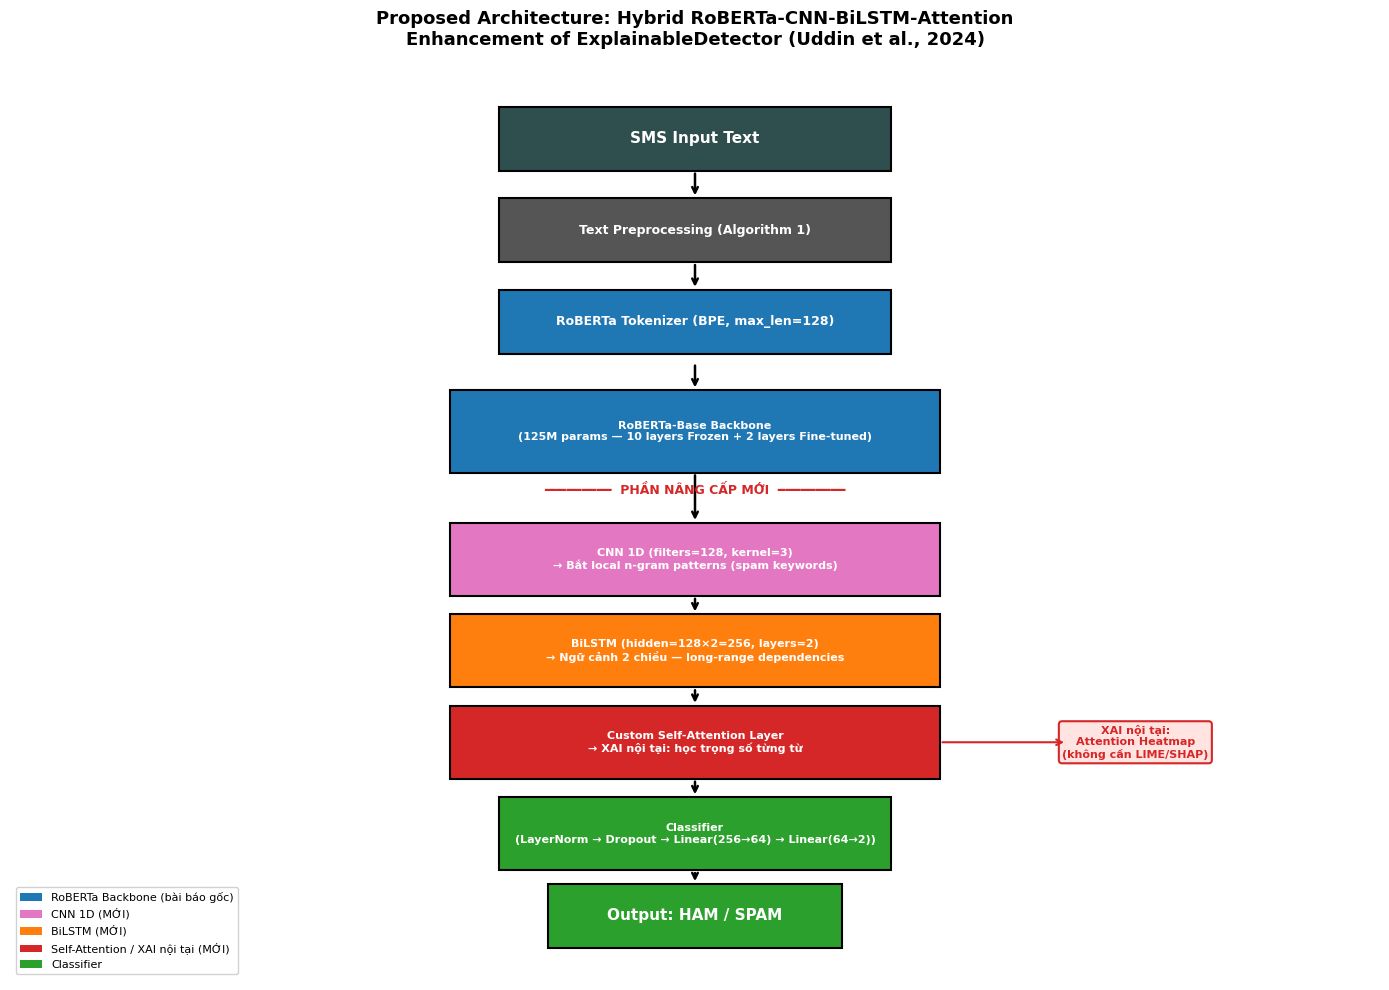

✅ Architecture saved! Tiếp tục Cell 17!


In [16]:
fig, ax = plt.subplots(figsize=(14, 10))
ax.set_xlim(0, 14); ax.set_ylim(0, 10)
ax.axis('off')

def box(ax, x, y, w, h, text, fc='#4472C4', tc='white', fs=9):
    r = plt.Rectangle((x-w/2, y-h/2), w, h,
                       facecolor=fc, edgecolor='black',
                       linewidth=1.5, zorder=3)
    ax.add_patch(r)
    ax.text(x, y, text, ha='center', va='center',
            fontsize=fs, color=tc, fontweight='bold',
            zorder=4, multialignment='center')

def arrow(ax, x1, y1, x2, y2, color='black'):
    ax.annotate('', xy=(x2,y2), xytext=(x1,y1),
                arrowprops=dict(arrowstyle='->',
                                color=color, lw=1.8), zorder=2)

# Input
box(ax, 7, 9.2, 4, 0.7, 'SMS Input Text', '#2F4F4F', fs=11)

# Preprocess
box(ax, 7, 8.2, 4, 0.7,
    'Text Preprocessing (Algorithm 1)', '#555', fs=9)
arrow(ax, 7, 8.85, 7, 8.55)

# Tokenizer
box(ax, 7, 7.2, 4, 0.7,
    'RoBERTa Tokenizer (BPE, max_len=128)', '#1F77B4', fs=9)
arrow(ax, 7, 7.85, 7, 7.55)

# RoBERTa
box(ax, 7, 6.0, 5, 0.9,
    'RoBERTa-Base Backbone\n(125M params — 10 layers Frozen + 2 layers Fine-tuned)',
    '#1F77B4', fs=8)
arrow(ax, 7, 6.75, 7, 6.45)

# Separator — NEW
ax.text(7, 5.35, '━━━━━━━━━  PHẦN NÂNG CẤP MỚI  ━━━━━━━━━',
        ha='center', va='center', fontsize=9,
        color='#D62728', fontweight='bold')

# CNN
box(ax, 7, 4.6, 5, 0.8,
    'CNN 1D (filters=128, kernel=3)\n→ Bắt local n-gram patterns (spam keywords)',
    '#E377C2', fs=8)
arrow(ax, 7, 5.55, 7, 5.0)

# BiLSTM
box(ax, 7, 3.6, 5, 0.8,
    'BiLSTM (hidden=128×2=256, layers=2)\n→ Ngữ cảnh 2 chiều — long-range dependencies',
    '#FF7F0E', fs=8)
arrow(ax, 7, 4.2, 7, 4.0)

# Attention
box(ax, 7, 2.6, 5, 0.8,
    'Custom Self-Attention Layer\n→ XAI nội tại: học trọng số từng từ',
    '#D62728', fs=8)
arrow(ax, 7, 3.2, 7, 3.0)

# Classifier
box(ax, 7, 1.6, 4, 0.8,
    'Classifier\n(LayerNorm → Dropout → Linear(256→64) → Linear(64→2))',
    '#2CA02C', fs=8)
arrow(ax, 7, 2.2, 7, 2.0)

# Output
box(ax, 7, 0.7, 3, 0.7, 'Output: HAM / SPAM', '#2CA02C', fs=11)
arrow(ax, 7, 1.2, 7, 1.05)

# XAI chú thích
ax.text(11.5, 2.6,
        'XAI nội tại:\nAttention Heatmap\n(không cần LIME/SHAP)',
        ha='center', va='center', fontsize=8,
        color='#D62728', fontweight='bold',
        bbox=dict(boxstyle='round', facecolor='#FFE4E1',
                  edgecolor='#D62728', linewidth=1.5))
ax.annotate('', xy=(9.5, 2.6), xytext=(10.8, 2.6),
            arrowprops=dict(arrowstyle='<-', color='#D62728', lw=1.5))

ax.set_title(
    'Proposed Architecture: Hybrid RoBERTa-CNN-BiLSTM-Attention\n'
    'Enhancement of ExplainableDetector (Uddin et al., 2024)',
    fontsize=13, fontweight='bold', pad=15
)

from matplotlib.patches import Patch
legend_elems = [
    Patch(facecolor='#1F77B4', label='RoBERTa Backbone (bài báo gốc)'),
    Patch(facecolor='#E377C2', label='CNN 1D (MỚI)'),
    Patch(facecolor='#FF7F0E', label='BiLSTM (MỚI)'),
    Patch(facecolor='#D62728', label='Self-Attention / XAI nội tại (MỚI)'),
    Patch(facecolor='#2CA02C', label='Classifier'),
]
ax.legend(handles=legend_elems, loc='lower left',
          fontsize=8, framealpha=0.9)

plt.tight_layout()
plt.savefig('/content/outputs_hybrid/architecture_hybrid.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Architecture saved! Tiếp tục Cell 17!")

In [17]:
import shutil
from google.colab import files

shutil.make_archive('/content/Stage4_Hybrid_outputs', 'zip',
                    '/content/outputs_hybrid')

print("📁 Tất cả file đã tạo:")
for f in sorted(os.listdir('/content/outputs_hybrid')):
    size = os.path.getsize(f'/content/outputs_hybrid/{f}')
    print(f"   {f}  ({size/1024:.0f} KB)")

files.download('/content/Stage4_Hybrid_outputs.zip')
print("\n🎉 HOÀN THÀNH GIAI ĐOẠN 4 — HYBRID MODEL!")

📁 Tất cả file đã tạo:
   architecture_hybrid.png  (154 KB)
   attention_ham1.png  (70 KB)
   attention_ham2.png  (45 KB)
   attention_spam1.png  (74 KB)
   attention_spam2.png  (74 KB)
   comparison_table.csv  (0 KB)
   confusion_matrix_hybrid.png  (38 KB)
   full_comparison.png  (90 KB)
   hybrid_best.pt  (490909 KB)
   roc_hybrid.png  (72 KB)
   training_curves.png  (126 KB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


🎉 HOÀN THÀNH GIAI ĐOẠN 4 — HYBRID MODEL!
